# Natural Language Processing with Disaster Tweets

**Task**  
Predict which Tweets are about real disasters and which ones are not.

**Columns:**
- ID
- Keyword
- Location
- Text
- Target (Only train.csv have)

**Link to dataset:**  
https://www.kaggle.com/competitions/nlp-getting-started/data

### Import Package

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.callbacks import ModelCheckpoint
from transformers import AutoTokenizer
from transformers import create_optimizer
from transformers import DataCollatorWithPadding
from transformers import TFAutoModelForSequenceClassification

os.environ["TOKENIZERS_PARALLELISM"] = "false" # Stop Warnings

2022-06-01 01:35:03.148123: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2022-06-01 01:35:03.148142: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
/usr/lib/python3/dist-packages/requests/__init__.py:89: RequestsDependencyWarning: urllib3 (1.26.9) or chardet (3.0.4) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "
/home/feng/.local/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Enabling GPU

In [ ]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  try:
    # Currently, memory growth needs to be the same across GPUs
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)

In [ ]:
plt.style.use('ggplot')

NameError: name 'plt' is not defined

### Read and Split Dataset

In [2]:
training_file = "dataset/train.csv"
test_file = "dataset/test.csv"
output_dir1 = './model2_outputs'
output_dir2 = './model3_outputs'
batch_size = 16

In [3]:
df = load_dataset('csv', data_files = [training_file])
df = df['train'].train_test_split(test_size = 0.1)
df['valid'] = df['test']
df['test'] = load_dataset('csv', data_files = [test_file])['train']

Using custom data configuration default-dacd6034bd90bc38
Reusing dataset csv (/home/feng/.cache/huggingface/datasets/csv/default-dacd6034bd90bc38/0.0.0/433e0ccc46f9880962cc2b12065189766fbb2bee57a221866138fb9203c83519)
100%|██████████| 1/1 [00:00<00:00, 1040.00it/s]
Using custom data configuration default-60f927a822212e41
Reusing dataset csv (/home/feng/.cache/huggingface/datasets/csv/default-60f927a822212e41/0.0.0/433e0ccc46f9880962cc2b12065189766fbb2bee57a221866138fb9203c83519)
100%|██████████| 1/1 [00:00<00:00, 259.58it/s]


#### Now we can observe the dataset

In [4]:
pd.DataFrame(df['train'])

,id,keyword,location,text,target
0,1810,buildings%20on%20fire,"Worcester, MA",MaFireEMS: RT WMUR9: Two buildings involved in...,1
1,1421,body%20bag,None,Nuu that FAM?? fwt I'm Leave You In a Body bag??,0
2,10628,wounded,USA,ABC News: Police Officer Wounded Suspect Dead ...,1
3,1454,body%20bagging,None,@amaramin3 Meek is definitely capable of body ...,0
4,5891,harm,"Cleveland, OH - San Diego, CA",IMAGINE A DOCTOR TREATING AN #EBOLA PATIENT WI...,1
...,...,...,...,...,...
6846,3837,detonate,Worldwide,Apollo Brown - Detonate (Ft. M.O.P.) https://t...,1
6847,4580,emergency%20plan,U.S. Northern Virginia,#Biztip We recommend all businesses to get an ...,1
6848,2458,collided,Toronto,Police investigating after an e-bike collided ...,1
6849,4276,drowning,University of Chicago,Epilepsy claims another. Common and still a ch...,0


In [ ]:
df['train'].isna().sum() # Count the missing value

In [5]:
pd.DataFrame(df['valid'])

,id,keyword,location,text,target
0,280,ambulance,Canada,ÛÏ@LeoBlakeCarter: This dog thinks he's an am...,0
1,5799,hail,"Dagenham, Essex",@chojo everyone hail to the pumpkin king!!!!,0
2,238,airplane%20accident,None,Experts in France begin examining airplane deb...,1
3,3623,desolation,None,Free Kindle Book - Aug 3-7 - Thriller - Desola...,0
4,5719,forest%20fire,None,@Sweet2Young -runs at her for setting my fores...,1
...,...,...,...,...,...
757,3109,debris,None,#?? #?? #??? #??? MH370: Aircraft debris found...,1
758,5999,hazardous,None,From recycling to only using non-hazardous che...,1
759,8729,sinking,None,Sinking carb consultative assembly plans could...,0
760,8116,rescued,southern california,A brave little dog gets rescued from the river...,0


In [ ]:
df['valid'].isna().sum() # Count the missing value

In [6]:
pd.DataFrame(df['test'])

,id,keyword,location,text
0,0,None,None,Just happened a terrible car crash
1,2,None,None,"Heard about #earthquake is different cities, s..."
2,3,None,None,"there is a forest fire at spot pond, geese are..."
3,9,None,None,Apocalypse lighting. #Spokane #wildfires
4,11,None,None,Typhoon Soudelor kills 28 in China and Taiwan
...,...,...,...,...
3258,10861,None,None,EARTHQUAKE SAFETY LOS ANGELES ÛÒ SAFETY FASTE...
3259,10865,None,None,Storm in RI worse than last hurricane. My city...
3260,10868,None,None,Green Line derailment in Chicago http://t.co/U...
3261,10874,None,None,MEG issues Hazardous Weather Outlook (HWO) htt...


In [ ]:
df['test'].isna().sum() # Count the missing value

Text(0, 0.5, 'Counts')

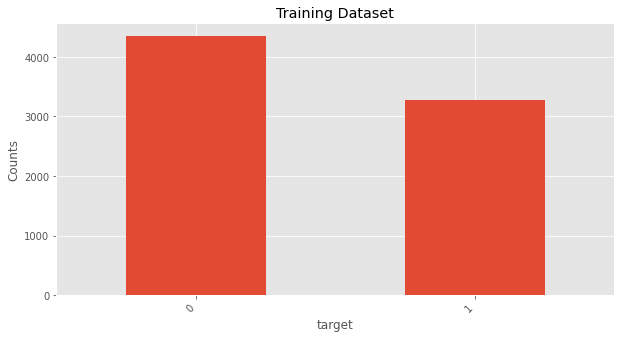

In [ ]:
reorder = [0, 1]

fig, axes = plt.subplots(figsize = (10, 5))

df['train'].value_counts('target').reindex(index = reorder).plot(kind = 'bar', ax = axes)
plt.sca(axes) # Set Axes
plt.xticks(rotation = 45, horizontalalignment = 'right')
plt.title('Training Dataset')
plt.ylabel('Counts')

## DistilBERT

Padding adds a special padding token to ensure shorter sequences will have the same length as either the longest sequence in a batch or the maximum length accepted by the model.

Truncation works in the other direction by truncating long sequences.

### Tokenize the Inputs

In [7]:
distilBERTtokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased") # Use Predefined Distilbert Tokenizer

def distilBERTtokenize(row):
    return distilBERTtokenizer(row["text"], padding = "max_length", truncation = True) # Padding and Truncation to Max Model Input Length

origin_columns = set(df["train"].features) # Not yet tokenized dataset
encoded_df = df.map(distilBERTtokenize, batched = True) # Open Batch Processing, Default Batch Size is 1000
tokenizer_columns = list(set(encoded_df["train"].features) - origin_columns)
print("Columns added by tokenizer:", tokenizer_columns)

100%|██████████| 1/1 [00:00<00:00,  9.58ba/s]

Columns added by tokenizer: ['attention_mask', 'input_ids']


In [8]:
df

DatasetDict({
    train: Dataset({
        features: ['id', 'keyword', 'location', 'text', 'target'],
        num_rows: 6851
    })
    test: Dataset({
        features: ['id', 'keyword', 'location', 'text'],
        num_rows: 3263
    })
    valid: Dataset({
        features: ['id', 'keyword', 'location', 'text', 'target'],
        num_rows: 762
    })
})

In [9]:
encoded_df

DatasetDict({
    train: Dataset({
        features: ['id', 'keyword', 'location', 'text', 'target', 'input_ids', 'attention_mask'],
        num_rows: 6851
    })
    test: Dataset({
        features: ['id', 'keyword', 'location', 'text', 'input_ids', 'attention_mask'],
        num_rows: 3263
    })
    valid: Dataset({
        features: ['id', 'keyword', 'location', 'text', 'target', 'input_ids', 'attention_mask'],
        num_rows: 762
    })
})

In [10]:
data_collator = DataCollatorWithPadding(tokenizer = distilBERTtokenizer, return_tensors = "tf")

train_df = encoded_df['train'].to_tf_dataset(
    columns = tokenizer_columns,
    label_cols = ["target"],
    shuffle = True,
    collate_fn = data_collator,
    batch_size = batch_size,
)

val_df = encoded_df['valid'].to_tf_dataset(
    columns = tokenizer_columns,
    label_cols = ["target"],
    shuffle = False,
    batch_size = batch_size,
    collate_fn = data_collator,
)

test_df = encoded_df['test'].to_tf_dataset(
    columns = tokenizer_columns,
    shuffle = False,
    batch_size = batch_size,
    collate_fn = data_collator,
)

2022-06-01 01:35:16.453806: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-06-01 01:35:16.454201: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-06-01 01:35:16.454617: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2022-06-01 01:35:16.454654: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2022-06-01 01:35:16.454688: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not lo

In [11]:
distilBERT_model = TFAutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels = 2
)

distilBERT_model.summary()

2022-06-01 01:35:18.373142: W tensorflow/python/util/util.cc:368] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.
Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['vocab_layer_norm', 'activation_13', 'vocab_projector', 'vocab_transform']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint 

Model: "tf_distil_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 distilbert (TFDistilBertMai  multiple                 66362880  
 nLayer)                                                         
                                                                 
 pre_classifier (Dense)      multiple                  590592    
                                                                 
 classifier (Dense)          multiple                  1538      
                                                                 
 dropout_19 (Dropout)        multiple                  0         
                                                                 
Total params: 66,955,010
Trainable params: 66,955,010
Non-trainable params: 0
_________________________________________________________________


In [12]:
num_epochs = 3
batches_per_epoch = len(encoded_df["train"]) // batch_size
total_train_steps = int(batches_per_epoch * num_epochs)

optimizer, schedule = create_optimizer(
    init_lr = 2e-5, num_warmup_steps = 0, num_train_steps = total_train_steps
)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True)
distilBERT_model.compile(optimizer = optimizer, loss = loss, metrics = ['accuracy'])

In [13]:
if not os.path.exists(output_dir1): # If the file directory doesn't already exists,
    os.makedirs(output_dir1) # Make it again

checkpoint_callback = ModelCheckpoint(filepath = output_dir1 + '/weights.{epoch:02d}.hdf5', monitor = 'val_loss', save_best_only = True, save_weights_only = True)

In [14]:
distilBERT_model.fit(
    train_df,
    validation_data = val_df,
    epochs = 3,
    callbacks = [checkpoint_callback],
)

Epoch 1/3
428/428 [==============================] - 2766s 6s/step - loss: 0.4332 - accuracy: 0.8093 - val_loss: 0.3978 - val_accuracy: 0.8281
Epoch 2/3
428/428 [==============================] - 2756s 6s/step - loss: 0.3150 - accuracy: 0.8746 - val_loss: 0.4119 - val_accuracy: 0.8412
Epoch 3/3
428/428 [==============================] - 2756s 6s/step - loss: 0.2414 - accuracy: 0.9146 - val_loss: 0.4479 - val_accuracy: 0.8399


### Predict and Output Test Dataset

In [15]:
test_pred = distilBERT_model.predict(test_df)

In [16]:
submission = pd.read_csv('dataset/sample_submission.csv')
submission['target'] = np.argmax(test_pred.logits, axis = 1)
submission.to_csv('submission.csv', index = False)

## BERT

### Tokenize the Inputs

In [17]:
BERTtokenizer = AutoTokenizer.from_pretrained("bert-base-uncased") # Use Predefined Distilbert Tokenizer

def BERTtokenize(row):
    return BERTtokenizer(row["text"], padding = "max_length", truncation = True) # Padding and Truncation to Max Model Input Length

origin_columns = set(df["train"].features) # Not yet tokenized dataset
encoded_df = df.map(BERTtokenize, batched = True) # Open Batch Processing, Default Batch Size is 1000
tokenizer_columns = list(set(encoded_df["train"].features) - origin_columns)
print("Columns added by tokenizer:", tokenizer_columns)

Downloading: 100%|██████████| 28.0/28.0 [00:00<00:00, 9.55kB/s]
Downloading: 100%|██████████| 570/570 [00:00<00:00, 200kB/s]
Downloading: 100%|██████████| 226k/226k [00:00<00:00, 286kB/s]  
Downloading: 100%|██████████| 455k/455k [00:00<00:00, 574kB/s] 
100%|██████████| 1/1 [00:00<00:00,  7.85ba/s]

Columns added by tokenizer: ['token_type_ids', 'input_ids', 'attention_mask']


In [18]:
data_collator = DataCollatorWithPadding(tokenizer = BERTtokenizer, return_tensors = "tf")

train_df = encoded_df['train'].to_tf_dataset(
    columns = tokenizer_columns,
    label_cols = ["target"],
    shuffle = True,
    collate_fn = data_collator,
    batch_size = batch_size,
)

val_df = encoded_df['valid'].to_tf_dataset(
    columns = tokenizer_columns,
    label_cols = ["target"],
    shuffle = False,
    batch_size = batch_size,
    collate_fn = data_collator,
)

test_df = encoded_df['test'].to_tf_dataset(
    columns = tokenizer_columns,
    shuffle = False,
    batch_size = batch_size,
    collate_fn = data_collator,
)

In [19]:
BERT_model = TFAutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels = 2
)

BERT_model.summary()

Downloading: 100%|██████████| 511M/511M [00:25<00:00, 21.4MB/s]   
All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: "tf_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bert (TFBertMainLayer)      multiple                  109482240 
                                                                 
 dropout_57 (Dropout)        multiple                  0         
                                                                 
 classifier (Dense)          multiple                  1538      
                                                                 
Total params: 109,483,778
Trainable params: 109,483,778
Non-trainable params: 0
_________________________________________________________________


In [20]:
num_epochs = 3
batches_per_epoch = len(encoded_df["train"]) // batch_size
total_train_steps = int(batches_per_epoch * num_epochs)

optimizer, schedule = create_optimizer(
    init_lr = 2e-5, num_warmup_steps = 0, num_train_steps = total_train_steps
)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True)
BERT_model.compile(optimizer = optimizer, loss = loss, metrics = ['accuracy'])

In [21]:
if not os.path.exists(output_dir2): # If the file directory doesn't already exists,
    os.makedirs(output_dir2) # Make it again

checkpoint_callback = ModelCheckpoint(filepath = output_dir2 + '/weights.{epoch:02d}.hdf5', monitor = 'val_loss', save_best_only = True, save_weights_only = True)

In [22]:
BERT_model.fit(
    train_df,
    validation_data = val_df,
    epochs = 3,
    callbacks = [checkpoint_callback],
)

Epoch 1/3
428/428 [==============================] - 5753s 13s/step - loss: 0.4414 - accuracy: 0.8058 - val_loss: 0.4074 - val_accuracy: 0.8386
Epoch 2/3
428/428 [==============================] - 5741s 13s/step - loss: 0.3164 - accuracy: 0.8773 - val_loss: 0.3926 - val_accuracy: 0.8333
Epoch 3/3
428/428 [==============================] - 5733s 13s/step - loss: 0.2342 - accuracy: 0.9163 - val_loss: 0.4706 - val_accuracy: 0.8268


### Predict and Output Test Dataset

In [23]:
test_pred = BERT_model.predict(test_df)

In [24]:
submission = pd.read_csv('dataset/sample_submission.csv')
submission['target'] = np.argmax(test_pred.logits, axis = 1)
submission.to_csv('submission2.csv', index = False)